
<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day3_movement_ecology/Day3_Part1_BasicSegmentaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# Day 3 Part 1: Trajectory Segmentation Methods

## Learning Objectives

By the end of this session, you will be able to:
- Visualize and explore 3D trajectory data from path integration tasks
- Implement multiple segmentation strategies:
1. **Time-Based**: Fixed temporal windows
2. **Heading-Based**: Directional changes  
3. **Straightness-Based**: Path linearity (RDP algorithm)
- Understand the trade-offs between different segmentation approaches
- Compare segmentation methods quantitatively
- Choose appropriate parameters for behavioral data

---

## Overview: What is Trajectory Segmentation?

**Trajectory segmentation** is the process of dividing a continuous path into discrete, meaningful segments. In behavioral analysis, this helps us:

1. **Identify behavioral phases**: outbound exploration, goal search, return navigation
2. **Detect transitions**: When does the animal change strategy?
3. **Quantify bout structure**: How long are exploration bouts?
4. **Compare strategies**: Do successful vs unsuccessful trials differ in segmentation?


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Packages imported")


✓ Packages imported


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/Workshop/Day3/sample_trials.csv'

## load the data from the GitHub repository
!curl -O https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/rat_pi/processed_long_trials.csv
df = pd.read_csv('processed_long_trials.csv')
print(f"Loaded {df['trial_id'].nunique()} trials")
display(df.head())
test_trial = df[df['trial_id'] == df['trial_id'].iloc[0]].copy()


Loaded 139 trials


,comp_time,time,trial_id,frame,success,visible,x,y,z,roll,yaw,pitch,rearing,goal_x,goal_z,session_id
0,1.642678e+09,0.00,0,0,1,1,-0.177946,0.684947,-0.538020,17.219877,130.408251,1.626639,1,-0.222463,-0.506765,20220120-122427
1,1.642678e+09,0.02,0,1,1,1,-0.176145,0.677317,-0.534851,15.862311,137.391134,-1.968877,1,-0.222463,-0.506765,20220120-122427
2,1.642678e+09,0.04,0,2,1,1,-0.173438,0.669224,-0.531853,11.622204,142.254633,-6.752198,0,-0.222463,-0.506765,20220120-122427
3,1.642678e+09,0.06,0,3,1,1,-0.171214,0.657547,-0.527501,10.051063,145.591786,-10.945343,0,-0.222463,-0.506765,20220120-122427
4,1.642678e+09,0.08,0,4,1,1,-0.168450,0.649601,-0.524621,9.225046,146.075703,-14.109203,0,-0.222463,-0.506765,20220120-122427


---

### Interactive 3D Trajectory Visualization

Let's visualize a single trial in 3D to understand the spatial structure of the behavior.

**What to look for:**
- Overall path shape (straight vs. circuitous)
- Vertical excursions (rearing events)
- Speed variations along the trajectory
- Goal-directed vs. exploratory segments


In [5]:
# =============================================================================
# INTERACTIVE 3D VISUALIZATION
# =============================================================================

def plot_trajectory_3d_interactive(df, trial_id):
    """
    Create interactive 3D plot of a single trial trajectory.
    
    Parameters:
    -----------
    df : DataFrame
        Full dataset
    trial_id : int
        Trial to visualize
    """
    # Extract trial data
    trial = df[df['trial_id'] == trial_id].copy()
    
    # Calculate speed for color coding
    dx = np.diff(trial['x'].values)
    dz = np.diff(trial['z'].values)
    dy = np.diff(trial['y'].values)
    dt = 1/120  # 120 Hz sampling
    
    speed = np.sqrt(dx**2 + dy**2 + dz**2) / dt
    speed = np.concatenate([[0], speed])  # Pad to match length
    trial['speed'] = speed
    
    # Create figure
    fig = go.Figure()
    
    # Main trajectory colored by speed
    fig.add_trace(go.Scatter3d(
        x=trial['x'],
        y=trial['z'],  # Swap y and z for better viewing
        z=trial['y'],
        mode='lines',
        line=dict(
            color=trial['speed'],
            colorscale='Viridis',
            width=4,
            colorbar=dict(title="Speed (cm/s)", x=1.1)
        ),
        name='Trajectory',
        hovertemplate='<b>Time:</b> %{text:.2f}s<br>' +
                      '<b>X:</b> %{x:.1f} cm<br>' +
                      '<b>Z:</b> %{y:.1f} cm<br>' +
                      '<b>Y:</b> %{z:.1f} cm<br>' +
                      '<b>Speed:</b> %{marker.color:.1f} cm/s<br>' +
                      '<extra></extra>',
        text=trial['time']
    ))
    
    # Start position (green)
    fig.add_trace(go.Scatter3d(
        x=[trial['x'].iloc[0]],
        y=[trial['z'].iloc[0]],
        z=[trial['y'].iloc[0]],
        mode='markers',
        marker=dict(size=10, color='green', symbol='circle'),
        name='Start',
        hovertext='Start Position'
    ))
    
    # Goal position (red star)
    goal_x = trial['goal_x'].iloc[0]
    goal_z = trial['goal_z'].iloc[0]
    fig.add_trace(go.Scatter3d(
        x=[goal_x],
        y=[goal_z],
        z=[0.5],  # Goal at ground level
        mode='markers',
        marker=dict(size=15, color='red', symbol='diamond'),
        name='Goal',
        hovertext=f'Goal Position ({goal_x:.1f}, {goal_z:.1f})'
    ))
    
    # Highlight rearing events
    rear_frames = trial[trial['rearing'] == 1]
    if len(rear_frames) > 0:
        fig.add_trace(go.Scatter3d(
            x=rear_frames['x'],
            y=rear_frames['z'],
            z=rear_frames['y'],
            mode='markers',
            marker=dict(size=5, color='orange', symbol='circle'),
            name='Rearing',
            hovertext='Rearing Event'
        ))
    
    # Update layout
    fig.update_layout(
        title=f'Trial {trial_id} - 3D Trajectory (Duration: {trial["time"].max():.1f}s)',
        scene=dict(
            xaxis_title='X Position (cm)',
            yaxis_title='Z Position (cm)',
            zaxis_title='Y Position (cm)',
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.2)
            )
        ),
        width=900,
        height=700,
        showlegend=True
    )
    
    fig.show()
    
    # Print summary statistics
    print(f"\nTrial {trial_id} Summary:")
    print(f"  Duration: {trial['time'].max():.2f} seconds")
    print(f"  Total frames: {len(trial)}")
    print(f"  Mean speed: {trial['speed'].mean():.2f} cm/s")
    print(f"  Max speed: {trial['speed'].max():.2f} cm/s")
    print(f"  Rearing events: {trial['rearing'].sum()}")
    print(f"  Total distance: {(trial['speed'] * dt).sum():.2f} cm")

# Visualize first trial
plot_trajectory_3d_interactive(df, trial_id=df['trial_id'].iloc[0])



Trial 0 Summary:
  Duration: 14.76 seconds
  Total frames: 739
  Mean speed: 0.78 cm/s
  Max speed: 21.56 cm/s
  Rearing events: 206
  Total distance: 4.82 cm


---

## Part 1: Time-Based Segmentation

### Concept: Fixed Time Windows

The simplest segmentation approach divides the trajectory into **equal-duration time windows**.

**Mathematical Definition:**

Given a trajectory with $N$ frames at sampling rate $f_s = 50$ Hz, we create segments of duration $\Delta t$ seconds:

$$
\text{Segment } i = \{\text{frames } k : i \cdot \Delta t \leq t_k < (i+1) \cdot \Delta t \}
$$

**Number of segments:**
$$
n_{\text{segments}} = \lceil \frac{T_{\text{total}}}{\Delta t} \rceil
$$

**Advantages:**
- Simple to implement
- Consistent temporal resolution across trials
- Easy to compare across animals/conditions

**Disadvantages:**
- Ignores spatial structure
- May split behaviorally-coherent bouts
- Requires choosing appropriate window size

---


In [ ]:
# =============================================================================
# TIME-BASED SEGMENTATION FUNCTION
# =============================================================================

def segment_by_time(trial_df, window_duration=2.0, sampling_rate=50):
    """
    Segment trajectory into fixed-duration time windows.
    
    Parameters:
    -----------
    trial_df : DataFrame
        Single trial data with 'time' column
    window_duration : float
        Duration of each segment in seconds
    sampling_rate : int
        Data sampling rate in Hz
    
    Returns:
    --------
    segments : DataFrame
        Original data with added 'segment_id' column
    segment_info : DataFrame
        Summary statistics for each segment
    """
    df = trial_df.copy()
    ## TODO: implement the segmentation based on time --- IGNORE ---
    # Assign segment ID based on time
    df['segment_id'] = (df['time'] // window_duration).astype(int)
    
    # Compute segment statistics
    segment_info = df.groupby('segment_id').agg({
        'time': ['min', 'max', 'count'],
        'x': ['mean', 'std'],
        'z': ['mean', 'std'],
        'y': ['mean', 'max'],
        'rearing': 'sum'
    }).reset_index()
    
    segment_info.columns = ['segment_id', 'start_time', 'end_time', 'n_frames',
                            'x_mean', 'x_std', 'z_mean', 'z_std',
                            'y_mean', 'y_max', 'n_rears']
    
    # Calculate additional features
    segment_info['duration'] = segment_info['end_time'] - segment_info['start_time']
    
    # Distance from start for each segment (using mean position)
    start_x, start_z = df['x'].iloc[0], df['z'].iloc[0]
    segment_info['dist_from_start'] = np.sqrt(
        (segment_info['x_mean'] - start_x)**2 + 
        (segment_info['z_mean'] - start_z)**2
    )
    
    # Distance to goal
    goal_x, goal_z = df['goal_x'].iloc[0], df['goal_z'].iloc[0]
    segment_info['dist_to_goal'] = np.sqrt(
        (segment_info['x_mean'] - goal_x)**2 + 
        (segment_info['z_mean'] - goal_z)**2
    )
    
    # Compute path length for each segment the displacement between the first and last point in the segment
    segment_info['path_length'] = np.nan  # Initialize with NaN

    for i, row in segment_info.iterrows():
        seg_df = df[df['segment_id'] == row['segment_id']]
        if len(seg_df) > 1:
            x_vals = seg_df['x'].values
            z_vals = seg_df['z'].values
            path_length = np.sum(np.sqrt(np.diff(x_vals)**2 + np.diff(z_vals)**2))
            segment_info.loc[i, 'path_length'] = path_length
    

    return df, segment_info


# Test the function
test_trial_id = df['trial_id'].iloc[0]
test_trial = df[df['trial_id'] == test_trial_id]

seg_time, stats_time = segment_by_time(test_trial, window_duration=2.0)

print(f"Trial {test_trial_id} segmented into {stats_time.shape[0]} segments")
print("\nSegment Statistics:")
display(stats_time)


Trial 0 segmented into 8 segments

Segment Statistics:


,segment_id,start_time,end_time,n_frames,x_mean,x_std,z_mean,z_std,y_mean,y_max,n_rears,duration,dist_from_start,dist_to_goal,path_length
0,0,0.0,1.98,100,-0.076362,0.034625,-0.590976,0.058556,0.668533,0.715929,80,1.98,0.114558,0.168632,0.370309
1,1,2.0,3.98,100,0.010523,0.116968,-0.483011,0.103361,0.532732,0.726559,57,1.98,0.196332,0.234194,0.610512
2,2,4.0,5.98,100,0.271237,0.024471,-0.037730,0.161698,0.451866,0.457214,0,1.98,0.672350,0.680980,0.664523
3,3,6.0,7.98,100,0.191752,0.076448,0.320983,0.053248,0.456941,0.466495,0,1.98,0.935180,0.925603,0.536345
4,4,8.0,9.98,100,-0.075246,0.088294,0.187849,0.051921,0.458680,0.474398,0,1.98,0.733098,0.710043,0.512762
5,5,10.0,11.98,100,-0.287397,0.014631,0.085262,0.122413,0.461216,0.464707,0,1.98,0.632818,0.595577,0.552334
6,6,12.0,13.98,100,-0.191045,0.066468,-0.432411,0.165133,0.504188,0.669276,50,1.98,0.106418,0.080720,0.719318
7,7,14.0,14.76,39,-0.193179,0.022786,-0.507726,0.057932,0.624091,0.681873,19,0.76,0.033908,0.029300,0.209826


In [ ]:

def segment_by_time(trial_df, window_duration=2.0, sampling_rate=50):
    """
    Segment trajectory into fixed-duration time windows.
    
    Parameters:
    -----------
    trial_df : DataFrame
        Single trial data with 'time' column
    window_duration : float
        Duration of each segment in seconds
    sampling_rate : int
        Data sampling rate in Hz
    
    Returns:
    --------
    segments : DataFrame
        Original data with added 'segment_id' column
    segment_info : DataFrame
        Summary statistics for each segment
    """
    df = trial_df.copy()
    ## TODO: implement the segmentation based on time --- IGNORE ---
    # Assign segment ID based on time
    df['segment_id'] = (df['time'] // window_duration).astype(int)
    
    # Compute segment statistics
    segment_info = df.groupby('segment_id').agg({
        'time': ['min', 'max', 'count'],
        'x': ['mean', 'std'],
        'z': ['mean', 'std'],
        'y': ['mean', 'max'],
        'rearing': 'sum'
    }).reset_index()
    
    segment_info.columns = ['segment_id', 'start_time', 'end_time', 'n_frames',
                            'x_mean', 'x_std', 'z_mean', 'z_std',
                            'y_mean', 'y_max', 'n_rears']
    
    # Calculate additional features
    segment_info['duration'] = segment_info['end_time'] - segment_info['start_time']
    
    # Distance from start for each segment (using mean position)
    start_x, start_z = df['x'].iloc[0], df['z'].iloc[0]
    segment_info['dist_from_start'] = np.sqrt(
        (segment_info['x_mean'] - start_x)**2 + 
        (segment_info['z_mean'] - start_z)**2
    )
    
    # Distance to goal
    goal_x, goal_z = df['goal_x'].iloc[0], df['goal_z'].iloc[0]
    segment_info['dist_to_goal'] = np.sqrt(
        (segment_info['x_mean'] - goal_x)**2 + 
        (segment_info['z_mean'] - goal_z)**2
    )
    
    # Compute path length for each segment the displacement between the first and last point in the segment
    segment_info['path_length'] = np.nan  # Initialize with NaN

    for i, row in segment_info.iterrows():
        seg_df = df[df['segment_id'] == row['segment_id']]
        if len(seg_df) > 1:
            x_vals = seg_df['x'].values
            z_vals = seg_df['z'].values
            path_length = np.sum(np.sqrt(np.diff(x_vals)**2 + np.diff(z_vals)**2))
            segment_info.loc[i, 'path_length'] = path_length
    

    return df, segment_info


### 🎯 Exercise 1: Parameter Exploration

**Task:** Modify the `window_duration` parameter and observe how it affects segmentation.

**Questions to consider:**
1. What happens with very small windows (0.5 sec)?
2. What happens with very large windows (10 sec)?
3. How do you choose an appropriate window size for this task?


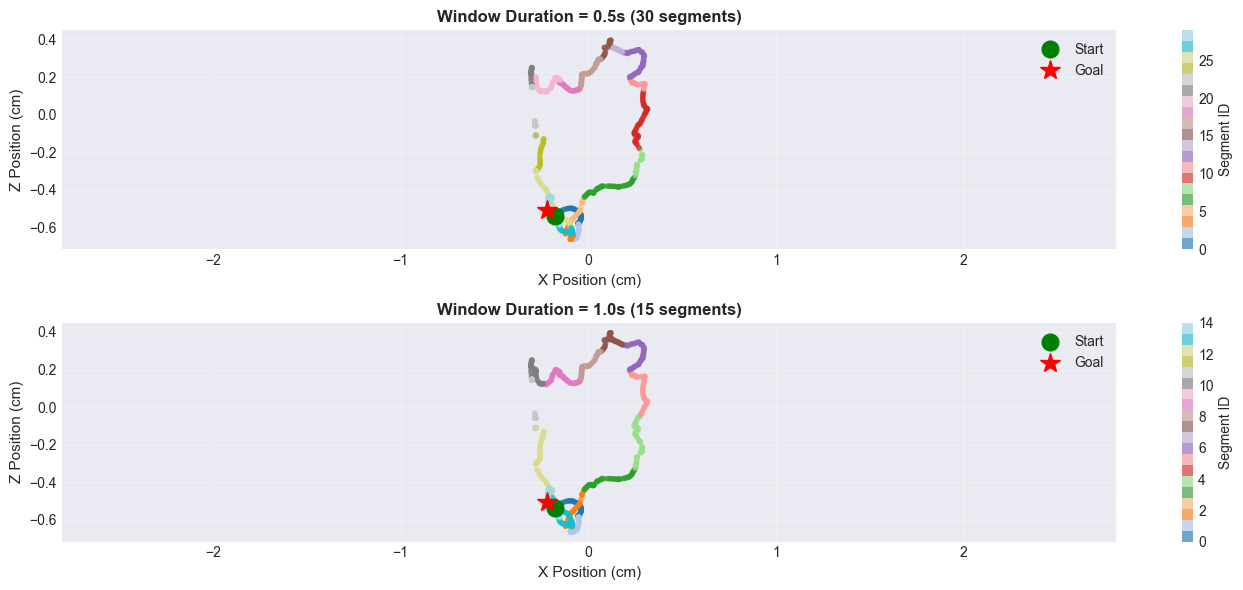


💡 Observation Questions:
  1. Which window duration captures distinct behavioral phases?
  2. At what duration do segments become too fine-grained?
  3. At what duration do segments merge different behaviors?


In [ ]:
# =============================================================================
# EXERCISE 1a: Experiment with Different Window Durations
# =============================================================================

# Try different window durations

## TODO: add more durations to explore --- IGNORE ---
window_durations = []  # in seconds
fig, axes = plt.subplots(len(window_durations), 1, figsize=(14, 3*len(window_durations)))

for idx, window_dur in enumerate(window_durations):
    # Segment the trial
    segmented, seg_stats = segment_by_time(test_trial, window_duration=window_dur)
    
    # Plot trajectory colored by segment
    ax = axes[idx]
    scatter = ax.scatter(segmented['x'], segmented['z'], 
                        c=segmented['segment_id'], 
                        cmap='tab20', s=10, alpha=0.6)
    
    # Mark start and goal
    ax.plot(test_trial['x'].iloc[0], test_trial['z'].iloc[0], 
           'go', markersize=12, label='Start', zorder=5)
    ax.plot(test_trial['goal_x'].iloc[0], test_trial['goal_z'].iloc[0], 
           'r*', markersize=15, label='Goal', zorder=5)
    
    ax.set_xlabel('X Position (cm)', fontsize=11)
    ax.set_ylabel('Z Position (cm)', fontsize=11)
    ax.set_title(f'Window Duration = {window_dur}s ({seg_stats.shape[0]} segments)', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Segment ID', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Observation Questions:")
print("  1. Which window duration captures distinct behavioral phases?")
print("  2. At what duration do segments become too fine-grained?")
print("  3. At what duration do segments merge different behaviors?")


---

## Part 2: Heading-Based Segmentation

Detect directional changes: $\theta = \arctan2(\Delta a1, \Delta a2)$, $\Delta\theta = \theta_i - \theta_{i-1}$

### 🎯 Calculate the heading direction

Q: how to find the correct axis when the information is not provided? Whether it is $\theta = \arctan2(\Delta z, \Delta x)$ or $\theta = \arctan2(\Delta x, \Delta z)$

Hint: when animal is moving fast, their movement direction is aligned with the head direction(yaw).




In [ ]:
## TODO: Implement Exercise 1b - Calculate Heading and Turning Angles --- IGNORE ---
## The immobility threshold can be adjusted based on the scale of the data and noise level.
##  You may want to experiment with different values to find the best fit for your dataset.

def calculate_heading_2d(x, z, immobility_threshold=0.0002):
    # Threshold for considering the animal as immobile
    dx, dz = np.diff(x), np.diff(z)
    ## TODO: compute heading using arctan2 --- IGNORE ---
    heading = None
    displacement = np.sqrt(dx**2 + dz**2)

    ## it is important to set the heading to NaN when the animal is immobile, otherwise small noise in position can cause large fluctuations in heading, which would lead to artificially high turning angles during immobility periods. By masking out these periods, we ensure that our analysis of turning behavior focuses on meaningful movements rather than noise-induced artifacts.
    heading[displacement < immobility_threshold] = np.nan 
    return heading

def calculate_turning_angles(heading):
    dh = np.diff(heading)
    return np.arctan2(np.sin(dh), np.cos(dh))

test_heading = calculate_heading_2d(test_trial['x'].values, test_trial['z'].values)
test_turning = calculate_turning_angles(test_heading)
print(f"Mean |turn|: {np.nanmean(np.abs(test_turning)):.3f} rad ({np.degrees(np.nanmean(np.abs(test_turning))):.1f}°)")


Mean |turn|: 0.322 rad (18.5°)


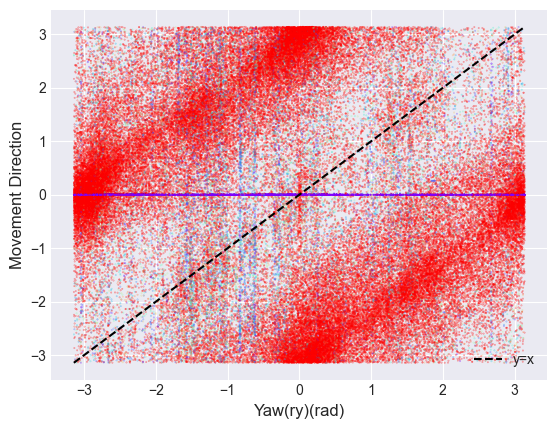

In [ ]:
# # solutions 

# x = df['x'].values
# z = df['z'].values
# ry = np.deg2rad(df['yaw'].values) if np.max(df['yaw'].values) > 2*np.pi else df['yaw'].values
# direction = np.arctan2(np.diff(x), np.diff(z))
# speed2d = np.sqrt(np.diff(x)**2 + np.diff(z)**2) * 120
# speed2d[speed2d > 0.2] = 0.2

# this_plot = plt.scatter(ry[1:], direction, c=speed2d, s=0.1, cmap='rainbow', alpha=0.5)
# plt.plot([-np.pi, np.pi], [-np.pi, np.pi], 'k--', label='y=x')
# plt.xlabel('Yaw(ry)(rad)', fontsize=12)
# plt.ylabel('Movement Direction', fontsize=12)
# plt.legend()



# def calculate_heading_2d(x, z, immobility_threshold=0.0002):
#     # Threshold for considering the animal as immobile
#     dx, dz = np.diff(x), np.diff(z)
#     heading = np.arctan2(dz, dx)
#     displacement = np.sqrt(dx**2 + dz**2)

#     ## it is important to set the heading to NaN when the animal is immobile, otherwise small noise in position can cause large fluctuations in heading, which would lead to artificially high turning angles during immobility periods. By masking out these periods, we ensure that our analysis of turning behavior focuses on meaningful movements rather than noise-induced artifacts.
#     heading[displacement < immobility_threshold] = np.nan 
#     return heading

[ 42  44  45  46  47  48  50  51  52  53  55  77  78  81  82  85  86  98
 112 117 118 130 131 132 133 152 157 161 162 163 173 174 192 193 203 229
 230 235 236 238 239 257 262 282 283 286 291 301 317 322 323 329 337 338
 347 348 358 366 367 368 372 373 376 377 382 383 384 385 390 391 393 401
 402 407 426 432 448 473 474 477 478 487 488 497 508 513 519 521 522 532
 591 602 684 705 731 732]
11 segments


,segment_id,start_time,end_time,n_frames,x_mean,z_mean,abs_turn_mean,n_rears,duration,dist_from_start,dist_to_goal,path_length
0,0,0.00,0.82,42,-0.081149,-0.531321,0.117058,22,0.82,0.097028,0.143432,0.212923
1,1,0.84,2.22,70,-0.077199,-0.633186,0.417089,70,1.38,0.138588,0.192572,0.188738
2,2,2.24,3.44,61,-0.042187,-0.503639,0.441062,45,1.20,0.140044,0.180303,0.377098
3,3,3.46,4.68,62,0.227916,-0.286188,0.241708,0,1.22,0.477643,0.501493,0.443937
4,4,4.70,6.00,66,0.272940,0.062605,0.293631,0,1.30,0.751031,0.754723,0.423291


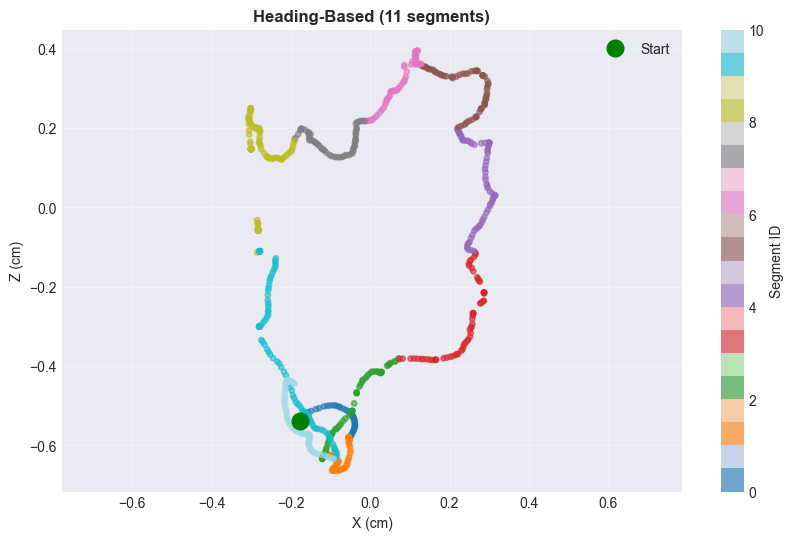

In [ ]:
def segment_by_heading(trial_df, turn_threshold=np.pi/4, min_segment_frames=60):
    df = trial_df.copy()
    heading = calculate_heading_2d(df['x'].values, df['z'].values)
    turning = calculate_turning_angles(heading)
    # Pad heading and turning to align with original data length
    df['heading'] = np.concatenate([[np.nan], heading])
    df['turning_angle'] = np.concatenate([[np.nan, np.nan], turning])
    
    ## TODO: identify turn points where absolute turning angle exceeds threshold --- IGNORE ---
    turn_points = None
    print(turn_points)
    if len(turn_points) > 0:
        filtered = [turn_points[0]]
        for tp in turn_points[1:]:
            if tp - filtered[-1] >= min_segment_frames:
                filtered.append(tp)
        turn_points = np.array(filtered)
    
    boundaries = np.concatenate([[0], turn_points, [len(df)]])
    segment_ids = np.zeros(len(df), dtype=int)
    for i in range(len(boundaries)-1):
        segment_ids[boundaries[i]:boundaries[i+1]] = i
    df['segment_id'] = segment_ids
    
    stats = df.groupby('segment_id').agg({
        'time': ['min', 'max', 'count'], 'x': 'mean', 'z': 'mean',
        'turning_angle': lambda x: np.nanmean(np.abs(x)), 'rearing': 'sum'
    }).reset_index()
    stats.columns = ['segment_id', 'start_time', 'end_time', 'n_frames', 'x_mean', 'z_mean', 'abs_turn_mean', 'n_rears']
    stats['duration'] = stats['end_time'] - stats['start_time']
    start_x, start_z = df['x'].iloc[0], df['z'].iloc[0]
    stats['dist_from_start'] = np.sqrt((stats['x_mean']-start_x)**2 + (stats['z_mean']-start_z)**2)
    
    # Distance to goal
    goal_x, goal_z = df['goal_x'].iloc[0], df['goal_z'].iloc[0]
    stats['dist_to_goal'] = np.sqrt((stats['x_mean']-goal_x)**2 + (stats['z_mean']-goal_z)**2)

    # path length for each segment
    stats['path_length'] = np.nan  # Initialize with NaN
    for i, row in stats.iterrows():
        seg_df = df[df['segment_id'] == row['segment_id']]
        if len(seg_df) > 1:
            x_vals = seg_df['x'].values
            z_vals = seg_df['z'].values
            path_length = np.sum(np.sqrt(np.diff(x_vals)**2 + np.diff(z_vals)**2))
            stats.loc[i, 'path_length'] = path_length
    
    return df, stats

seg_heading, stats_heading = segment_by_heading(test_trial, np.pi/6, 60)
print(f"{stats_heading.shape[0]} segments")
display(stats_heading.head())

plt.figure(figsize=(10,6))
scatter = plt.scatter(seg_heading['x'], seg_heading['z'], c=seg_heading['segment_id'], cmap='tab20', s=15, alpha=0.6)
plt.plot(test_trial['x'].iloc[0], test_trial['z'].iloc[0], 'go', markersize=12, label='Start')
plt.xlabel('X (cm)'); plt.ylabel('Z (cm)')
plt.title(f'Heading-Based ({stats_heading.shape[0]} segments)', fontweight='bold')
plt.legend(); plt.axis('equal'); plt.colorbar(scatter, label='Segment ID'); plt.grid(alpha=0.3); plt.show()


In [ ]:
# def segment_by_heading(trial_df, turn_threshold=np.pi/4, min_segment_frames=60):
#     df = trial_df.copy()
#     heading = calculate_heading_2d(df['x'].values, df['z'].values)
#     turning = calculate_turning_angles(heading)
#     # Pad heading and turning to align with original data length
#     df['heading'] = np.concatenate([[np.nan], heading])
#     df['turning_angle'] = np.concatenate([[np.nan, np.nan], turning])
    
#     abs_turning = np.abs(df['turning_angle'].values)
#     turn_points = np.where(abs_turning > turn_threshold)[0] 
#     print(turn_points)
#     if len(turn_points) > 0:
#         filtered = [turn_points[0]]
#         for tp in turn_points[1:]:
#             if tp - filtered[-1] >= min_segment_frames:
#                 filtered.append(tp)
#         turn_points = np.array(filtered)
    
#     boundaries = np.concatenate([[0], turn_points, [len(df)]])
#     segment_ids = np.zeros(len(df), dtype=int)
#     for i in range(len(boundaries)-1):
#         segment_ids[boundaries[i]:boundaries[i+1]] = i
#     df['segment_id'] = segment_ids
    
#     stats = df.groupby('segment_id').agg({
#         'time': ['min', 'max', 'count'], 'x': 'mean', 'z': 'mean',
#         'turning_angle': lambda x: np.nanmean(np.abs(x)), 'rearing': 'sum'
#     }).reset_index()
#     stats.columns = ['segment_id', 'start_time', 'end_time', 'n_frames', 'x_mean', 'z_mean', 'abs_turn_mean', 'n_rears']
#     stats['duration'] = stats['end_time'] - stats['start_time']
#     start_x, start_z = df['x'].iloc[0], df['z'].iloc[0]
#     stats['dist_from_start'] = np.sqrt((stats['x_mean']-start_x)**2 + (stats['z_mean']-start_z)**2)
    
#     # Distance to goal
#     goal_x, goal_z = df['goal_x'].iloc[0], df['goal_z'].iloc[0]
#     stats['dist_to_goal'] = np.sqrt((stats['x_mean']-goal_x)**2 + (stats['z_mean']-goal_z)**2)

#     # path length for each segment
#     stats['path_length'] = np.nan  # Initialize with NaN
#     for i, row in stats.iterrows():
#         seg_df = df[df['segment_id'] == row['segment_id']]
#         if len(seg_df) > 1:
#             x_vals = seg_df['x'].values
#             z_vals = seg_df['z'].values
#             path_length = np.sum(np.sqrt(np.diff(x_vals)**2 + np.diff(z_vals)**2))
#             stats.loc[i, 'path_length'] = path_length
    
#     return df, stats

[  3   4  42  44  45  46  47  48  50  51  52  53  55  56  65  66  77  78
  79  80  81  82  83  84  85  86  87  91  96  98 108 112 113 117 118 130
 131 132 133 151 152 153 155 157 159 160 161 162 163 167 168 170 172 173
 174 183 192 193 195 197 201 202 203 206 228 229 230 231 233 234 235 236
 238 239 241 243 246 251 252 256 257 258 261 262 263 265 266 276 281 282
 283 286 287 288 289 291 294 296 297 301 304 317 322 323 324 329 331 337
 338 340 341 343 345 347 348 352 353 358 360 363 365 366 367 368 372 373
 375 376 377 378 382 383 384 385 390 391 392 393 399 401 402 403 404 407
 412 416 423 426 429 431 432 435 436 441 443 444 445 446 447 448 449 451
 452 453 454 455 459 471 473 474 476 477 478 480 481 487 488 489 492 497
 500 504 508 510 512 513 517 519 521 522 523 527 528 531 532 533 591 602
 605 621 626 634 642 648 653 654 659 666 667 672 678 680 682 684 685 687
 694 695 698 702 705 706 731 732 737]
[ 42  44  45  46  47  48  50  51  52  53  55  77  78  81  82  85  86  98
 112 117 118 

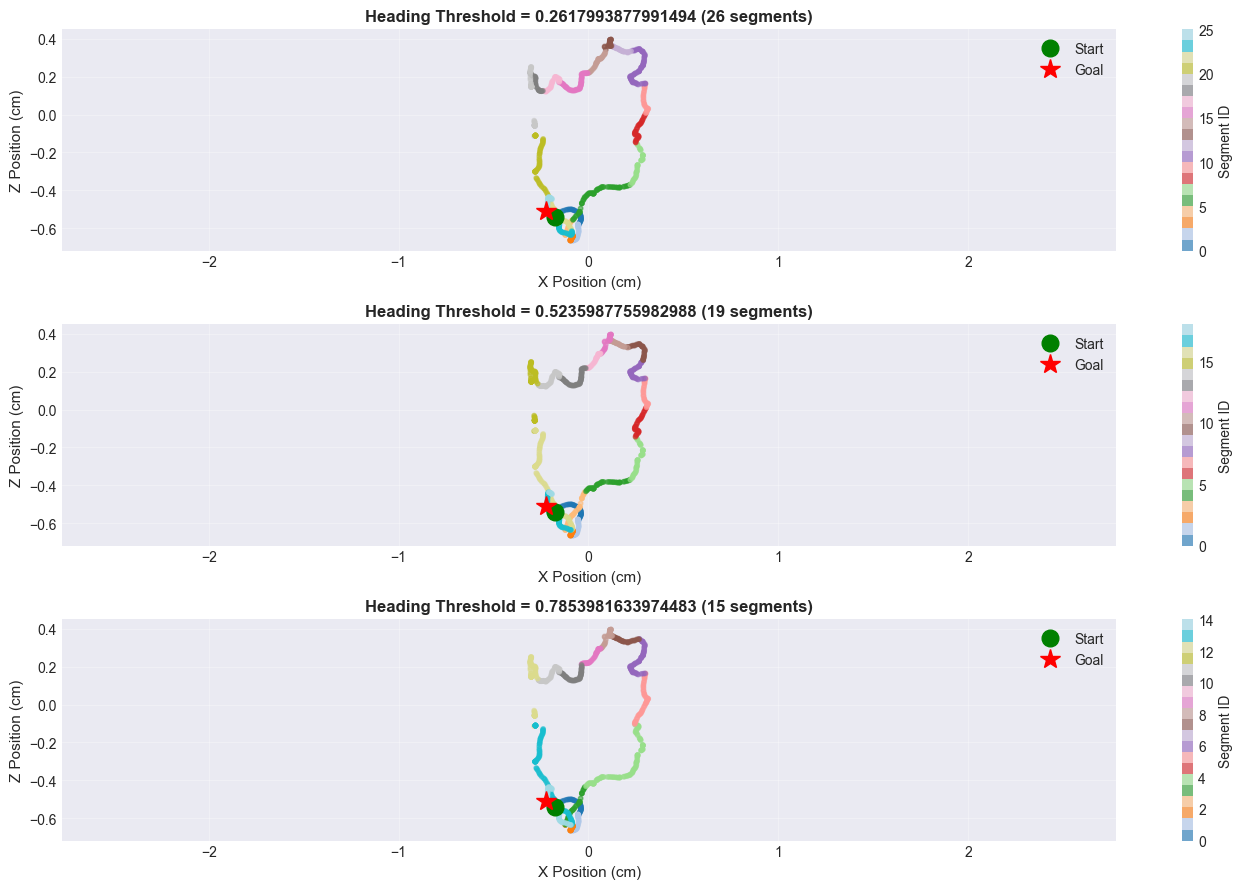


💡 Observation Questions:
  1. Which heading threshold captures distinct behavioral phases?
  2. At what threshold do segments become too fine-grained?
  3. At what threshold do segments merge different behaviors?


In [ ]:
# =============================================================================
# EXERCISE 3: Experiment with Different heading-based Segmentation Thresholds
# =============================================================================


## TODO: add more straightness thresholds to explore --- IGNORE ---
heading_thresholds = []  # in radians

fig, axes = plt.subplots(len(heading_thresholds), 1, figsize=(14, 3*len(heading_thresholds)))

for idx, threshold in enumerate(heading_thresholds):
    # Segment the trial
    segmented, seg_stats = segment_by_heading(test_trial, turn_threshold=threshold,min_segment_frames=25)
    
    
    # Plot trajectory colored by segment
    ax = axes[idx]
    scatter = ax.scatter(segmented['x'], segmented['z'], 
                        c=segmented['segment_id'], 
                        cmap='tab20', s=10, alpha=0.6)
    
    # Mark start and goal
    ax.plot(test_trial['x'].iloc[0], test_trial['z'].iloc[0], 
           'go', markersize=12, label='Start', zorder=5)
    ax.plot(test_trial['goal_x'].iloc[0], test_trial['goal_z'].iloc[0], 
           'r*', markersize=15, label='Goal', zorder=5)
    
    ax.set_xlabel('X Position (cm)', fontsize=11)
    ax.set_ylabel('Z Position (cm)', fontsize=11)
    ax.set_title(f'Heading Threshold = {threshold} ({seg_stats.shape[0]} segments)', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Segment ID', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Observation Questions:")
print("  1. Which heading threshold captures distinct behavioral phases?")
print("  2. At what threshold do segments become too fine-grained?")
print("  3. At what threshold do segments merge different behaviors?")


---
## Part 3: Segmentation by Path Straightness

### 3.1 What is Straightness?

**Straightness ratio** measures how direct a path is between two points:

$$\text{Straightness} = \frac{\text{Euclidean Distance}}{\text{Path Length}}$$

- **Euclidean Distance**: The straight-line "as the crow flies" distance from start to end
- **Path Length**: The actual distance traveled along the trajectory

#### Interpreting Straightness Values

- **Straightness = 1.0**: Perfectly straight line (shortest possible path)
- **Straightness < 0.5**: Highly tortuous or circuitous path

#### Why Does This Matter for Behavior?

Different behavioral states often have characteristic path straightness:
- **Straight runs**: Goal-directed movement, exploration of new areas
- **Curved paths**: Turning, searching behavior, wall-following
- **Tortuous paths**: Local exploration, foraging, indecision

By segmenting trajectories based on straightness, we can identify when an animal
switches between these different movement patterns.

STRAIGHTNESS ANALYSIS - First 100 Frames
Straightness Ratio: 0.240
Euclidean Distance: 0.14 cm
Path Length:        0.57 cm
Extra Distance:     0.43 cm (317.5% longer)


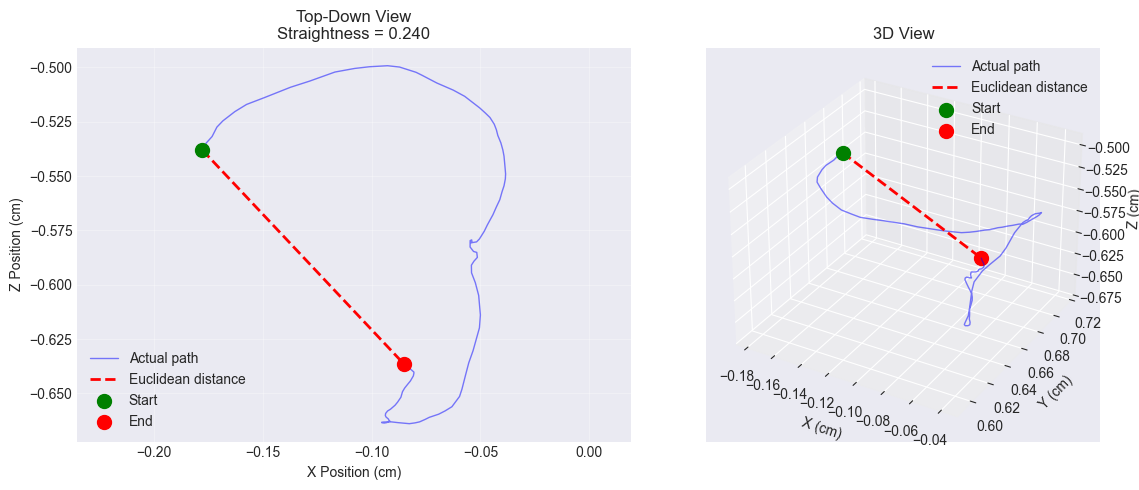

In [12]:
def point_to_line_distance(point, line_start, line_end):
    if np.all(np.equal(line_start, line_end)):
        return np.linalg.norm(point - line_start)
    cross = np.cross(line_end - line_start, line_start - point)
    return np.linalg.norm(cross) / np.linalg.norm(line_end - line_start)

def calculate_straightness_ratio(positions, start_idx, end_idx):
    '''
    Calculate straightness ratio for a segment defined by start and end indices.
    Straightness ratio = (Euclidean distance from start to end) / (Total path length)
        - Ratio close to 1 indicates a straight segment
    positions: Nx3 array of (x, y, z) coordinates or Nx2 if only (x, z) are used
    start_idx: index of segment start
    end_idx: index of segment end
    '''
    segment = positions[start_idx:end_idx+1]
    euclidean_dist = np.linalg.norm(segment[-1] - segment[0])
    step_distances = np.linalg.norm(np.diff(segment, axis=0), axis=1)
    path_length = np.sum(step_distances)
    ratio = euclidean_dist / path_length if path_length > 0 else 0.0
    return ratio, euclidean_dist, path_length


# Extract position data from our test trial
## THINK - Should we use (x, z) or (x, y, z) for straightness?
test_pos = test_trial[['x', 'y', 'z']].values

# Calculate straightness for the first 100 frames
ratio, euc, path = calculate_straightness_ratio(test_pos, 0, 100)

print("=" * 60)
print("STRAIGHTNESS ANALYSIS - First 100 Frames")
print("=" * 60)
print(f"Straightness Ratio: {ratio:.3f}")
print(f"Euclidean Distance: {euc:.2f} cm")
print(f"Path Length:        {path:.2f} cm")
print(f"Extra Distance:     {path - euc:.2f} cm ({(path/euc - 1)*100:.1f}% longer)")
print("=" * 60)

# Visualize what this segment looks like
fig = plt.figure(figsize=(12, 5))

# 2D view (top-down)
ax1 = fig.add_subplot(121)
segment_100 = test_pos[0:101]
ax1.plot(segment_100[:, 0], segment_100[:, 2], 'b-', alpha=0.5, linewidth=1, label='Actual path')
ax1.plot([segment_100[0, 0], segment_100[-1, 0]], 
         [segment_100[0, 2], segment_100[-1, 2]], 
         'r--', linewidth=2, label='Euclidean distance')
ax1.scatter(segment_100[0, 0], segment_100[0, 2], color='green', s=100, zorder=5, label='Start')
ax1.scatter(segment_100[-1, 0], segment_100[-1, 2], color='red', s=100, zorder=5, label='End')
ax1.set_xlabel('X Position (cm)')
ax1.set_ylabel('Z Position (cm)')
ax1.set_title(f'Top-Down View\nStraightness = {ratio:.3f}')
ax1.legend()
ax1.axis('equal')
ax1.grid(alpha=0.3)

# 3D view
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(segment_100[:, 0], segment_100[:, 1], segment_100[:, 2], 
         'b-', alpha=0.5, linewidth=1, label='Actual path')
ax2.plot([segment_100[0, 0], segment_100[-1, 0]], 
         [segment_100[0, 1], segment_100[-1, 1]],
         [segment_100[0, 2], segment_100[-1, 2]], 
         'r--', linewidth=2, label='Euclidean distance')
ax2.scatter(*segment_100[0], color='green', s=100, label='Start')
ax2.scatter(*segment_100[-1], color='red', s=100, label='End')
ax2.set_xlabel('X (cm)')
ax2.set_ylabel('Y (cm)')
ax2.set_zlabel('Z (cm)')
ax2.set_title('3D View')
ax2.legend()

plt.tight_layout()
plt.show()



---

### 3.2 The Ramer-Douglas-Peucker (RDP) Algorithm

The RDP algorithm is a classic method for simplifying curves while preserving their shape.
We'll adapt it to find natural breakpoints in trajectories.

### How It Works

1. **Draw a line** from the start to the end of the trajectory segment
2. **Find the point** farthest from this line
3. **Check straightness**: Is the segment straight enough?
   - If YES → Keep as one segment
   - If NO → Split at the farthest point and recursively process each half


16 segments


,segment_id,straightness,path_length
0,0,0.319538,0.501206
1,1,0.568928,0.119638
2,2,0.861062,0.375137
3,3,0.876611,0.328101
4,4,0.857007,0.463594


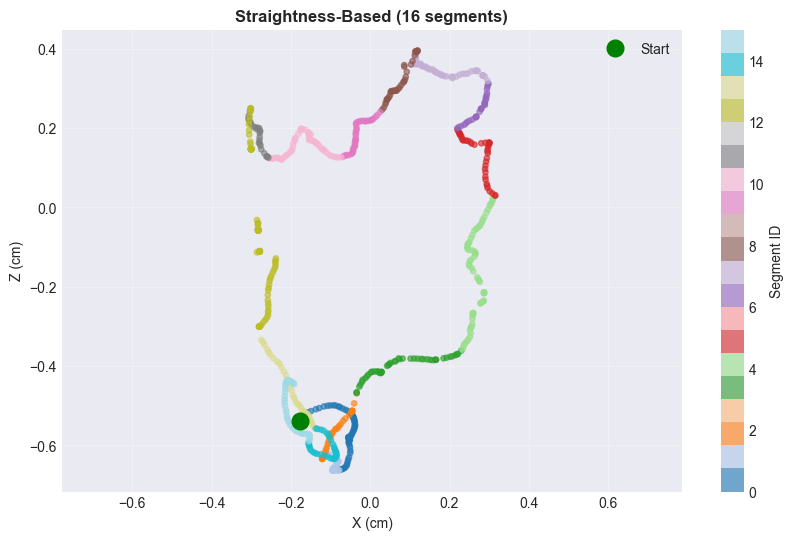

In [13]:

def rdp_segment_recursive(positions, start_idx, end_idx, straightness_threshold=0.85, min_segment_length=10):
    '''
     Recursive implementation of Ramer-Douglas-Peucker algorithm for trajectory segmentation.
     positions: Nx3 array of (x, y, z) coordinates or Nx2 if
                only (x, z) are used
    start_idx: index of segment start
    end_idx: index of segment end
    straightness_threshold: minimum straightness ratio to consider a segment straight
    min_segment_length: minimum number of frames for a valid segment, will not split if either side is too short
    '''
    max_dist, max_idx = 0.0, start_idx
    for i in range(start_idx + 1, end_idx):
        dist = point_to_line_distance(positions[i], positions[start_idx], positions[end_idx])
        if dist > max_dist:
            max_dist, max_idx = dist, i
    
    straightness, _, _ = calculate_straightness_ratio(positions, start_idx, end_idx)
    left_len, right_len = max_idx - start_idx, end_idx - max_idx
    
    if straightness < straightness_threshold and left_len >= min_segment_length and right_len >= min_segment_length:
        left = rdp_segment_recursive(positions, start_idx, max_idx, straightness_threshold, min_segment_length)
        right = rdp_segment_recursive(positions, max_idx, end_idx, straightness_threshold, min_segment_length)
        return left + right[1:]
    return [start_idx, end_idx]

def segment_by_straightness(trial_df, straightness_threshold=0.85, min_segment_frames=60):
    '''
    Segment trajectory based on straightness using Ramer-Douglas-Peucker algorithm.
    trial_df: DataFrame for a single trial with 'x', 'y', 'z
    straightness_threshold: minimum straightness ratio to consider a segment straight
    min_segment_frames: minimum number of frames for a valid segment, will not split if either side is too short
    '''

    df = trial_df.copy()
    positions = df[['x', 'y', 'z']].values
    boundaries = rdp_segment_recursive(positions, 0, len(positions)-1, straightness_threshold, min_segment_frames)
    
    segment_ids = np.zeros(len(df), dtype=int)
    for seg_num in range(len(boundaries)-1):
        start, end = boundaries[seg_num], boundaries[seg_num+1]
        segment_ids[start:end] = seg_num
    segment_ids[boundaries[-1]:] = len(boundaries)-2
    df['segment_id'] = segment_ids
    
    segment_info_list = []
    for seg_id in range(len(boundaries)-1):
        start, end = boundaries[seg_id], boundaries[seg_id+1]
        segment = df.iloc[start:end+1]
        straightness, euclidean, path_len = calculate_straightness_ratio(positions, start, end)
        segment_info_list.append({
            'segment_id': seg_id, 'start_time': segment['time'].min(), 'end_time': segment['time'].max(),
            'n_frames': len(segment), 'straightness': straightness, 'path_length': path_len,
            'x_mean': segment['x'].mean(), 'z_mean': segment['z'].mean()
        })
    
    stats = pd.DataFrame(segment_info_list)
    stats['duration'] = stats['end_time'] - stats['start_time']
    return df, stats

## TEST THE STRAIGHTNESS-BASED SEGMENTATION
seg_straight, stats_straight = segment_by_straightness(test_trial, 0.9, 25)
print(f"{stats_straight.shape[0]} segments")
display(stats_straight[['segment_id', 'straightness', 'path_length']].head())

plt.figure(figsize=(10,6))
scatter = plt.scatter(seg_straight['x'], seg_straight['z'], c=seg_straight['segment_id'], cmap='tab20', s=15, alpha=0.6)
plt.plot(test_trial['x'].iloc[0], test_trial['z'].iloc[0], 'go', markersize=12, label='Start')
plt.xlabel('X (cm)'); plt.ylabel('Z (cm)')
plt.title(f'Straightness-Based ({stats_straight.shape[0]} segments)', fontweight='bold')
plt.legend(); plt.axis('equal'); plt.colorbar(scatter, label='Segment ID'); plt.grid(alpha=0.3); plt.show()


### 🎯 Exercise : Parameter exploration for straightness 

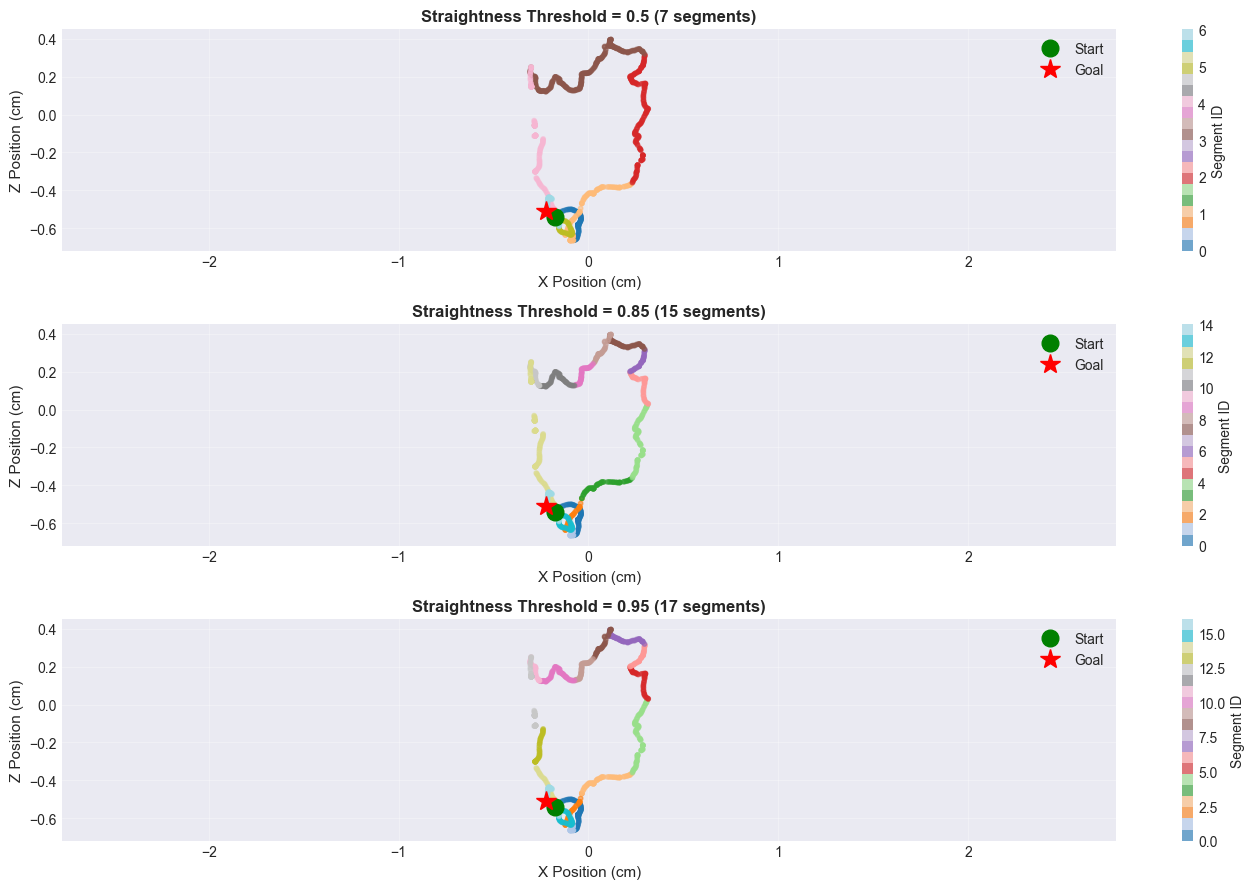


💡 Observation Questions:
  1. Which straightness threshold captures distinct behavioral phases?
  2. At what threshold do segments become too fine-grained?
  3. At what threshold do segments merge different behaviors?


In [14]:
# =============================================================================
# EXERCISE 1a: Experiment with Different Window Durations
# =============================================================================


## TODO: add more straightness thresholds to explore --- IGNORE ---
straightness_thresholds = [0.5, 0.85, 0.95]

fig, axes = plt.subplots(len(straightness_thresholds), 1, figsize=(14, 3*len(straightness_thresholds)))

for idx, threshold in enumerate(straightness_thresholds):
    # Segment the trial
    segmented, seg_stats = segment_by_straightness(test_trial, straightness_threshold=threshold,min_segment_frames=25)
    
    
    # Plot trajectory colored by segment
    ax = axes[idx]
    scatter = ax.scatter(segmented['x'], segmented['z'], 
                        c=segmented['segment_id'], 
                        cmap='tab20', s=10, alpha=0.6)
    
    # Mark start and goal
    ax.plot(test_trial['x'].iloc[0], test_trial['z'].iloc[0], 
           'go', markersize=12, label='Start', zorder=5)
    ax.plot(test_trial['goal_x'].iloc[0], test_trial['goal_z'].iloc[0], 
           'r*', markersize=15, label='Goal', zorder=5)
    
    ax.set_xlabel('X Position (cm)', fontsize=11)
    ax.set_ylabel('Z Position (cm)', fontsize=11)
    ax.set_title(f'Straightness Threshold = {threshold} ({seg_stats.shape[0]} segments)', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Segment ID', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Observation Questions:")
print("  1. Which straightness threshold captures distinct behavioral phases?")
print("  2. At what threshold do segments become too fine-grained?")
print("  3. At what threshold do segments merge different behaviors?")


---

## Part 4: Method Comparison

Now let's compare all three segmentation methods side-by-side to understand their trade-offs.


**Some Evaluation Criteria:**
1. **Number of segments**: How many segments does each method create?
2. **Segment size distribution**: Are segments uniform or variable?
3. **Behavioral alignment**: Do segments correspond to meaningful behaviors?
4. **Feature consistency**: How do segment features (speed, curvature) vary?

Discuss: how to choose the the criteria, besides what mentioned above, what is important? 


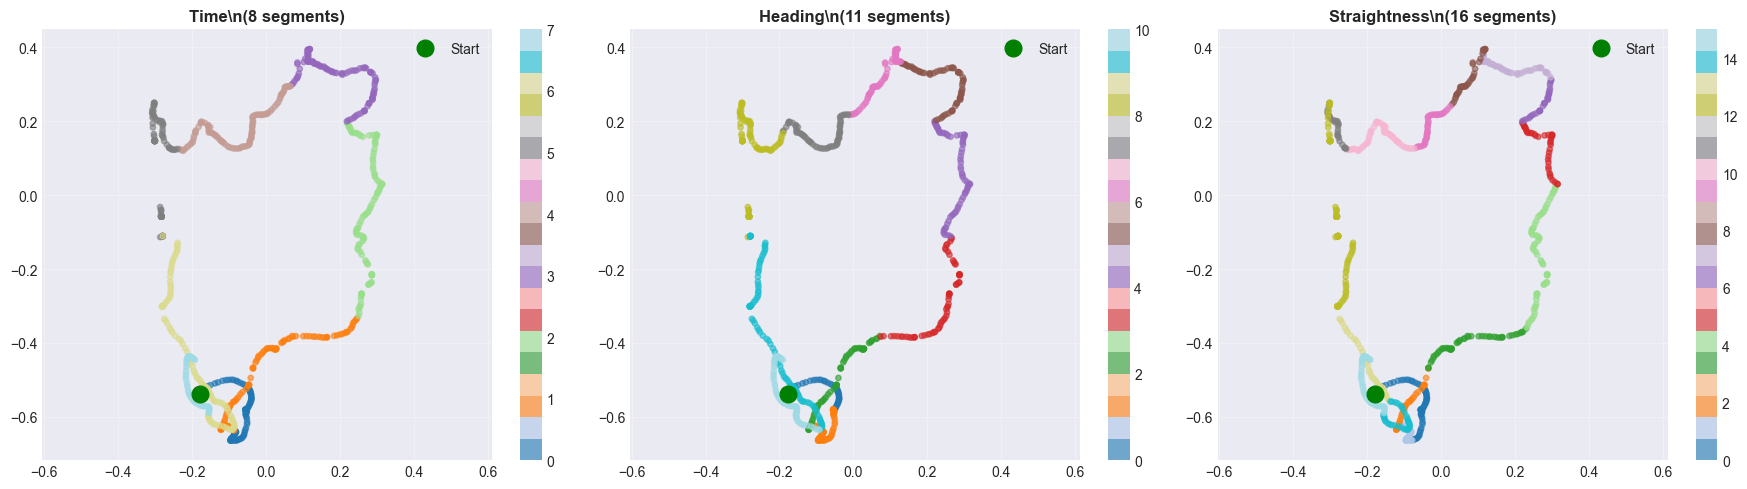

,Method,N Segments,Mean Duration (s)
0,Time,8,1.827500
1,Heading,11,1.323636
2,Straightness,16,0.922500


In [15]:
methods = ['Time', 'Heading', 'Straightness']
seg_dfs = [seg_time, seg_heading, seg_straight]
stats_list = [stats_time, stats_heading, stats_straight]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (seg_df, stats, name) in enumerate(zip(seg_dfs, stats_list, methods)):
    scatter = axes[idx].scatter(seg_df['x'], seg_df['z'], c=seg_df['segment_id'], cmap='tab20', s=15, alpha=0.6)
    axes[idx].plot(test_trial['x'].iloc[0], test_trial['z'].iloc[0], 'go', markersize=12, label='Start')
    axes[idx].set_title(f'{name}\\n({stats.shape[0]} segments)', fontweight='bold')
    axes[idx].legend(); axes[idx].axis('equal'); axes[idx].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[idx])
plt.tight_layout(); plt.show()

comparison = pd.DataFrame({
    'Method': methods,
    'N Segments': [s.shape[0] for s in stats_list],
    'Mean Duration (s)': [s['duration'].mean() for s in stats_list]
})
display(comparison)


---

## Part 5: Apply to Full Dataset


In [16]:
FULL_DATA_PATH  = '../../data/processed_long_trials.csv'

try:
    df_full = pd.read_csv(FULL_DATA_PATH)
except:
    df_full = df.copy()

def segment_all_trials(df, method='time', **params):
    all_segments, all_stats = [], []
    for trial_id in df['trial_id'].unique():
        trial = df[df['trial_id'] == trial_id]
        if method == 'time':
            seg, stats = segment_by_time(trial, **params)
        elif method == 'heading':
            seg, stats = segment_by_heading(trial, **params)
        elif method == 'straightness':
            seg, stats = segment_by_straightness(trial, **params)
        stats['trial_id'] = trial_id
        all_segments.append(seg); all_stats.append(stats)
    return pd.concat(all_segments, ignore_index=True), pd.concat(all_stats, ignore_index=True)

all_seg, all_stats = segment_all_trials(df_full, 'straightness', straightness_threshold=0.85, min_segment_frames=25)
print(f"Segmented {df_full['trial_id'].nunique()} trials → {all_stats.shape[0]} segments")


Segmented 139 trials → 2073 segments


### what can it reveal? 

Rememebr that the purpose of segmentation should be sepecific to the task, to the scientifical question. 

Considering that the task here is a path-integration task, there will be outbound and inbound for each trial. We can try to check if the segmentaion 

In [ ]:
## get the results for different methods
## TODO: add more methods and parameters to explore --- IGNORE ---
results = {}
for method, para in [('time', {'window_duration': 2.0}), 
                 ('heading', {'turn_threshold': np.pi/6, 'min_segment_frames': 60}), 
                 ('straightness', {'straightness_threshold': 0.9, 'min_segment_frames': 10})]:
    all_seg, all_stats = segment_all_trials(df_full, method, **para)
    results[method] = (all_seg, all_stats)

In [18]:
all_stats

,segment_id,start_time,end_time,n_frames,straightness,path_length,x_mean,z_mean,duration,trial_id
0,0,0.00,0.30,16,0.857212,0.157482,-0.136770,-0.514229,0.30,0
1,1,0.30,0.78,25,0.913857,0.151649,-0.047892,-0.537236,0.48,0
2,2,0.78,1.16,20,0.841303,0.107671,-0.052799,-0.586465,0.38,0
3,3,1.16,1.40,13,0.891603,0.084404,-0.062280,-0.646197,0.24,0
4,4,1.40,2.28,45,0.568928,0.119638,-0.092628,-0.646461,0.88,0
...,...,...,...,...,...,...,...,...,...,...
4904,39,18.76,18.98,12,0.940106,0.019103,0.048378,0.207920,0.22,138
4905,40,18.98,19.96,50,0.955765,0.314681,0.094829,0.137430,0.98,138
4906,41,19.96,20.30,18,0.924015,0.147719,0.218456,0.004525,0.34,138
4907,42,20.30,20.56,14,0.964005,0.060366,0.209932,0.045898,0.26,138


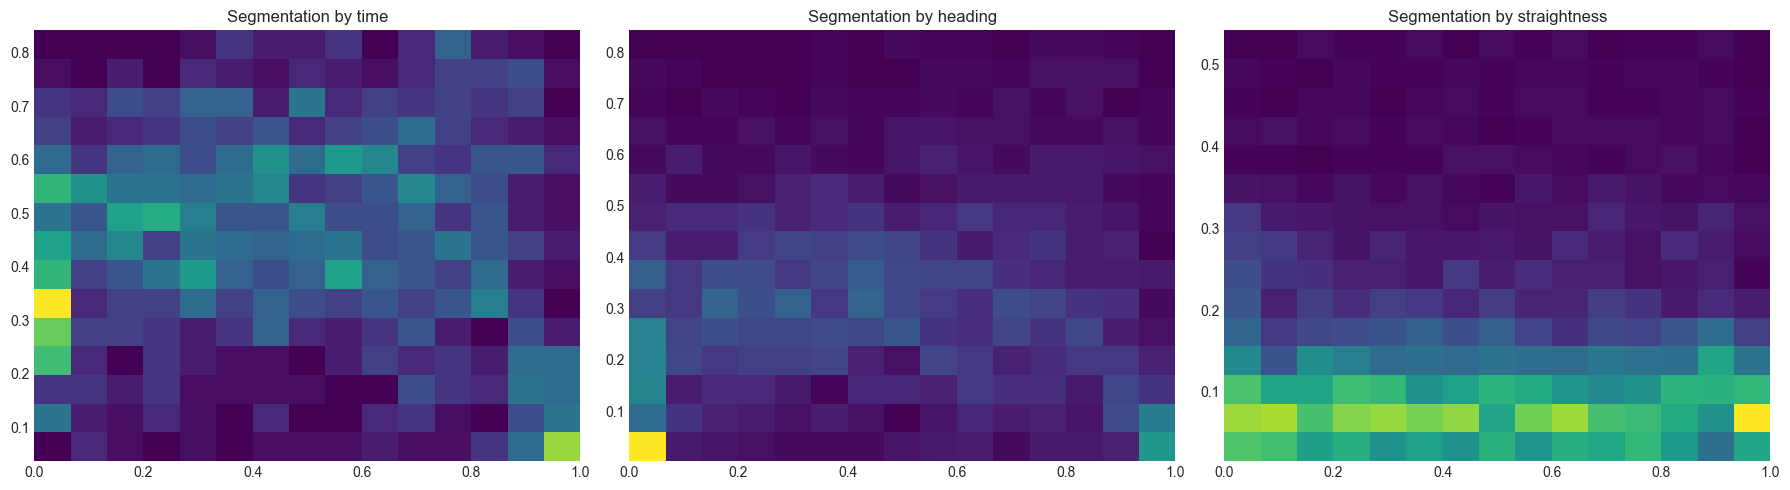

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, method in enumerate(results.keys()):
    all_seg, all_stats = results[method]
    norm_time = (all_stats.groupby('trial_id')['duration'].cumsum() - all_stats['duration'])/all_stats.groupby('trial_id')['duration'].transform('sum')
    # remove the nan
    sec_value = all_stats['path_length'].replace([np.inf, -np.inf], np.nan).dropna()
    norm_time = norm_time[sec_value.index]
    ranges = [[0,1],[np.percentile(sec_value, 2), np.percentile(sec_value, 98)]]
    axes[idx].hist2d(norm_time, sec_value, bins=15, cmap='viridis', range=ranges)
    axes[idx].set_title(f'Segmentation by {method}')
plt.tight_layout(); plt.show()

## Disucssion 

Is this something you expect? 

What does the data tell you?

What would you try?


---

## Summary and Key Takeaways

### What We Learned

1. **Three Segmentation Approaches**:
   - **Time-based**: Simple, uniform temporal windows
   - **Displacement-based**: Captures equal movement amounts
   - **Curvature-based**: Detects geometric turning points

2. **Method Trade-offs**:
   - Time-based is easiest but ignores spatial structure
   - Displacement-based captures path progress but has variable durations
   - Straightness aligns with natural behavior changes

3. **Parameter Selection**:
   - Window duration, distance threshold, and curvature threshold must be tuned
   - Optimal parameters depend on behavior type and experimental question
   - Visualization is key for validation

---

### Next Steps: Change Point Detection (Part 2)

In the next session, we'll address a key question:

**How can we automatically detect when behavioral states change?**

We'll use **change point detection** algorithms to find transitions between behavioral phases without pre-defining segment boundaries.

**Preview:**
- Ruptures library for change point detection
- Dynamic programming and kernel methods
- Validating detected changes against ground truth
- Comparing segmentation vs. change point detection

---

**End of Part 1**
